# GBM drift and volatility with Nested Sampling

The goal of this notebook is to infer the annualized drift `mu` and volatility `sigma` of a stock under the Geometric Brownian Motion model, using Nested Sampling with `dynesty`.

The experiment is done year by year: for each calendar year, we use one year of prices and compute weekly log-returns. This makes the drift-identification problem visible instead of hiding it inside one long historical average.

# Theoretical introduction:

Under GBM,

$$dS_t = \mu S_t dt + \sigma S_t dW_t$$

and the log-return over a time interval `dt` is normally distributed:

$$r_t = \log \left(\frac{S_t}{S_0}\right) \sim \mathcal{N}\left((\mu - \frac{1}{2}\sigma^2)dt, \sigma^2 dt\right).$$

This gives us a likelihood for the observed stock log-returns.

## Notation

* `mu`: annualized stock drift
* `sigma`: annualized stock volatility
* `estimation window`: one calendar year
* `return_window`: number of trading days used for each log-return
* `dt = return_window / 252`: return horizon in years
* `theta = [mu, sigma]`: parameter vector sampled by `dynesty`

In [ ]:
import warnings

import dynesty
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import yfinance as yf
from dynesty import plotting as dyplot
from dynesty.utils import quantile

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')

## Experiment setup

We estimate drift and volatility separately for each year. The return horizon is set to one trading week, i.e. approximately 5 trading days. This is arbitrary and can be changed later by changing `return_window`.

In [20]:
stock_name = 'AAPL'
start_year = 2000
end_year = 2023

# one week of trading days
return_window = 5
dt = return_window / 252

# non-overlapping weekly returns avoid pretending we have more independent data than we do
use_non_overlapping_returns = True

# broad annualized priors
mu_min, mu_max = -2.0, 2.0
sigma_min, sigma_max = 0.01, 3.0

# nested-sampling controls
nlive = 300
dlogz = 0.05
maxiter = 100000
maxcall = 500000
random_seed = 123

print(f'stock: {stock_name}')
print(f'years: {start_year}-{end_year}')
print(f'return window: {return_window} trading days')
print(f'dt: {dt:.5f} years')

stock: AAPL
years: 2000-2023
return window: 5 trading days
dt: 0.01984 years


## Data: stock prices and weekly log-returns

We download all prices once, then split by calendar year.

In [21]:
downloaded = yf.download(
    stock_name,
    start=f'{start_year}-01-01',
    end=f'{end_year + 1}-01-01',
    auto_adjust=False,
    progress=False,
)

prices = downloaded['Close']
if isinstance(prices, pd.DataFrame):
    prices = prices.iloc[:, 0]

prices = prices.dropna()
prices.head()

Date
2000-01-03    0.999442
2000-01-04    0.915179
2000-01-05    0.928571
2000-01-06    0.848214
2000-01-07    0.888393
Name: AAPL, dtype: float64

In [22]:
def get_year_prices(prices, year):
    return prices.loc[prices.index.year == year].dropna()


def get_log_returns(year_prices, return_window=5, non_overlapping=True):
    if non_overlapping:
        sampled_prices = year_prices.iloc[::return_window]
        log_returns = np.log(sampled_prices / sampled_prices.shift(1)).dropna()
    else:
        log_returns = np.log(year_prices / year_prices.shift(return_window)).dropna()

    return log_returns.to_numpy()


def get_year_log_returns(prices, year, return_window=5, non_overlapping=True):
    year_prices = get_year_prices(prices, year)
    log_returns = get_log_returns(year_prices, return_window, non_overlapping)
    return year_prices, log_returns

In [23]:
year_counts = []

for year in range(start_year, end_year + 1):
    year_prices, year_log_returns = get_year_log_returns(
        prices,
        year,
        return_window=return_window,
        non_overlapping=use_non_overlapping_returns,
    )

    year_counts.append({
        'year': year,
        'price_observations': len(year_prices),
        'return_observations': len(year_log_returns),
    })

year_counts = pd.DataFrame(year_counts)
year_counts

,year,price_observations,return_observations
0,2000,252,50
1,2001,248,49
2,2002,252,50
3,2003,252,50
4,2004,252,50
5,2005,252,50
6,2006,251,50
7,2007,251,50
8,2008,253,50
9,2009,252,50


### Prior transform

Nested Sampling specifies priors through a transform from the unit cube `U(0, 1)^D` to the physical parameter space.

Here we use finite uniform priors:

$$\mu \sim U(\mu_{min}, \mu_{max})$$

$$\sigma \sim U(\sigma_{min}, \sigma_{max}).$$

In [24]:
def prior_transform(u):
    x = np.array(u)

    ### drift ###
    x[0] = x[0] * (mu_max - mu_min)
    x[0] = x[0] + mu_min

    ### volatility ###
    x[1] = x[1] * (sigma_max - sigma_min)
    x[1] = x[1] + sigma_min

    return x

### Likelihood

For running `dynesty` we construct the log-likelihood `loglike(theta)`, where `theta = [mu, sigma]`.

For observed log-returns `r`,

$$\log L(\theta) = \sum_i \log \mathcal{N}\left(r_i \mid (\mu - \frac{1}{2}\sigma^2)dt, \sigma\sqrt{dt}\right).$$

In [25]:
def make_loglike(log_returns, dt):
    def loglike(theta):
        mu, sigma = theta

        if sigma <= 0:
            return -np.inf

        mean = (mu - 0.5 * sigma**2) * dt
        std = sigma * np.sqrt(dt)
        residual = (log_returns - mean) / std

        return -0.5 * np.sum(residual**2 + np.log(2 * np.pi * std**2))

    return loglike

Before running all years, inspect one example year. This follows the same one-problem Nested Sampling framework as the nested-sampling intro notebook.

In [26]:
example_year = 2023
example_prices, example_log_returns = get_year_log_returns(
    prices,
    example_year,
    return_window=return_window,
    non_overlapping=use_non_overlapping_returns,
)

loglike = make_loglike(example_log_returns, dt)

print(f'example year: {example_year}')
print(f'price observations: {len(example_prices)}')
print(f'return observations: {len(example_log_returns)}')

example year: 2023
price observations: 250
return observations: 49


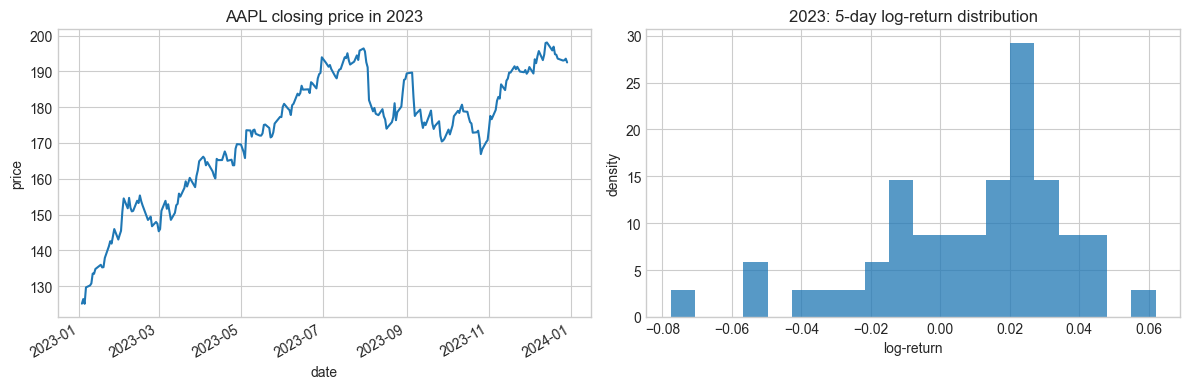

In [27]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

example_prices.plot(ax=axes[0], title=f'{stock_name} closing price in {example_year}')
axes[0].set_xlabel('date')
axes[0].set_ylabel('price')

axes[1].hist(example_log_returns, bins=20, density=True, alpha=0.75)
axes[1].set_title(f'{example_year}: {return_window}-day log-return distribution')
axes[1].set_xlabel('log-return')
axes[1].set_ylabel('density')

fig.tight_layout()

A likelihood surface is not required by Nested Sampling, but it helps reveal the weak drift direction.

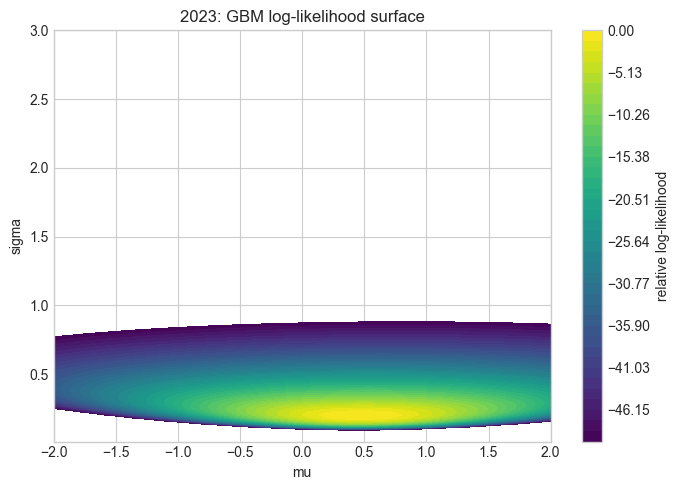

In [28]:
mu_grid = np.linspace(mu_min, mu_max, 140)
sigma_grid = np.linspace(sigma_min, sigma_max, 140)
MU, SIGMA = np.meshgrid(mu_grid, sigma_grid)
LL = np.empty_like(MU)

for i in range(MU.shape[0]):
    for j in range(MU.shape[1]):
        LL[i, j] = loglike([MU[i, j], SIGMA[i, j]])

LL_relative = LL - np.nanmax(LL)

plt.figure(figsize=(7, 5))
plt.contourf(MU, SIGMA, LL_relative, levels=np.linspace(-50, 0, 40), cmap='viridis')
plt.colorbar(label='relative log-likelihood')
plt.xlabel('mu')
plt.ylabel('sigma')
plt.title(f'{example_year}: GBM log-likelihood surface')
plt.tight_layout()

### Performing Nested Sampling Inference with "dynesty"

Nested Sampling in `dynesty` is done via a high-level `sampler` object. The required arguments are the log-likelihood, the prior transform, and the number of dimensions.

In [29]:
# additionally you can seed the random number generator for reproducibility
rstate = np.random.default_rng(random_seed)

# initialize sampler
sampler = dynesty.NestedSampler(
    loglike,
    prior_transform,
    ndim=2,
    nlive=nlive,
    rstate=rstate,
)

Sampling from the target distribution is done using the `run_nested()` function in the provided sampler.

In [30]:
# start the run
sampler.run_nested(dlogz=dlogz, maxiter=maxiter, maxcall=maxcall)

2779it [00:01, 1694.03it/s, +300 | bound: 9 | nc: 1 | ncall: 14401 | eff(%): 21.835 | loglstar:   -inf < 106.026 <    inf | logz: 99.800 +/-  0.131 | dlogz:  0.000 >  0.050]


Sampling results can be accessed through the `results` property.

In [ ]:
# get results
results = sampler.results

We can print a quick summary of the run using `summary()`, which provides information about the evidence estimate, number of likelihood calls, and sampling efficiency.

In [ ]:
results.summary()

#### Live Points

The number of live points is the main resolution parameter. Increasing `nlive` improves posterior and evidence resolution, but increases runtime.

### Stopping criteria

The run above uses `dlogz`, which stops once the remaining evidence contribution is small. The limits `maxiter` and `maxcall` are included to prevent accidental very long runs.

### Visualizing results

#### Summary plots

A summary run plot shows how the sampler compresses prior volume, climbs the likelihood, and accumulates evidence.

In [ ]:
fig, axes = dyplot.runplot(results, color='darkorange', logplot=True)
fig.tight_layout()

#### Traces and Posteriors

The trace plot shows particle evolution in prior volume and the corresponding marginalized posterior distributions.

In [ ]:
parameter_labels = [r'$\mu$', r'$\sigma$']

fig, axes = dyplot.traceplot(
    results,
    labels=parameter_labels,
    show_titles=True,
    trace_cmap='viridis',
    connect=True,
    connect_highlight=range(10),
)
fig.tight_layout()

The corner plot gives the one-dimensional and two-dimensional posterior structure for `mu` and `sigma`.

In [ ]:
fg, axs = dyplot.cornerplot(
    results,
    labels=parameter_labels,
    show_titles=True,
)

### Doing science I: Understanding parameter estimation and posterior generation

The raw nested-sampling samples are not all equally weighted. To obtain posterior estimates and credible intervals, use `results.samples` together with `results.importance_weights()`.

In [ ]:
samples = results.samples
weights = results.importance_weights()

plt.figure(figsize=(6, 5))
plt.scatter(samples[:, 0], samples[:, 1], c=weights, s=8, cmap='viridis')
plt.colorbar(label='importance weight')
plt.xlabel('mu')
plt.ylabel('sigma')
plt.title(f'{example_year}: nested-sampling samples')
plt.tight_layout()

Compute the 95% credible interval from the weighted posterior samples.

In [ ]:
def posterior_summary_from_results(results):
    samples = results.samples
    weights = results.importance_weights()

    summary = {}
    for name, values in [('mu', samples[:, 0]), ('sigma', samples[:, 1])]:
        low, mid, high = quantile(values, [0.025, 0.5, 0.975], weights=weights)
        mean = np.average(values, weights=weights)
        std = np.sqrt(np.average((values - mean)**2, weights=weights))

        summary[f'{name}_mean'] = mean
        summary[f'{name}_std'] = std
        summary[f'{name}_q025'] = low
        summary[f'{name}_median'] = mid
        summary[f'{name}_q975'] = high

    return summary

In [ ]:
example_summary = posterior_summary_from_results(results)
pd.DataFrame([example_summary])

# Year-by-year Nested Sampling

Now run the same Nested Sampling framework for every calendar year.

In [ ]:
def run_nested_for_year(year):
    year_prices, year_log_returns = get_year_log_returns(
        prices,
        year,
        return_window=return_window,
        non_overlapping=use_non_overlapping_returns,
    )

    if len(year_log_returns) < 10:
        return None

    loglike_year = make_loglike(year_log_returns, dt)
    rstate_year = np.random.default_rng(random_seed + year)

    sampler_year = dynesty.NestedSampler(
        loglike_year,
        prior_transform,
        ndim=2,
        nlive=nlive,
        rstate=rstate_year,
    )

    sampler_year.run_nested(
        dlogz=dlogz,
        maxiter=maxiter,
        maxcall=maxcall,
        print_progress=False,
    )

    results_year = sampler_year.results
    summary = posterior_summary_from_results(results_year)

    summary.update({
        'year': year,
        'price_observations': len(year_prices),
        'return_observations': len(year_log_returns),
        'logz': results_year.logz[-1],
        'logzerr': results_year.logzerr[-1],
    })

    return summary

In [ ]:
yearly_results = []

for year in range(start_year, end_year + 1):
    print(f'Running nested sampling for {year}...')
    result = run_nested_for_year(year)

    if result is not None:
        yearly_results.append(result)

yearly_summary = pd.DataFrame(yearly_results).sort_values('year').reset_index(drop=True)
yearly_summary

## Drift over years

The posterior interval for drift should usually be wide. If the interval crosses zero, that year does not provide strong evidence for a nonzero drift under this model.

In [ ]:
fig, ax = plt.subplots(figsize=(12, 5))

mu_lower = yearly_summary['mu_median'] - yearly_summary['mu_q025']
mu_upper = yearly_summary['mu_q975'] - yearly_summary['mu_median']

ax.errorbar(
    yearly_summary['year'],
    yearly_summary['mu_median'],
    yerr=[mu_lower, mu_upper],
    fmt='o-',
    capsize=3,
    label='mu median and 95% credible interval',
)

ax.axhline(0, color='black', linewidth=1, linestyle='--')
ax.set_xlabel('year')
ax.set_ylabel('annualized drift mu')
ax.set_title(f'{stock_name}: yearly drift inference from {return_window}-day returns')
ax.legend()
fig.tight_layout()

## Volatility over years

Volatility is usually identified more sharply because it is estimated from the dispersion of returns, not from the small average return.

In [ ]:
fig, ax = plt.subplots(figsize=(12, 5))

sigma_lower = yearly_summary['sigma_median'] - yearly_summary['sigma_q025']
sigma_upper = yearly_summary['sigma_q975'] - yearly_summary['sigma_median']

ax.errorbar(
    yearly_summary['year'],
    yearly_summary['sigma_median'],
    yerr=[sigma_lower, sigma_upper],
    fmt='o-',
    capsize=3,
    color='darkorange',
    label='sigma median and 95% credible interval',
)

ax.set_xlabel('year')
ax.set_ylabel('annualized volatility sigma')
ax.set_title(f'{stock_name}: yearly volatility inference from {return_window}-day returns')
ax.legend()
fig.tight_layout()

## Drift versus volatility uncertainty

A direct way to summarize the main point is to compare the posterior interval widths for `mu` and `sigma` across years.

In [ ]:
yearly_summary['mu_ci_width'] = yearly_summary['mu_q975'] - yearly_summary['mu_q025']
yearly_summary['sigma_ci_width'] = yearly_summary['sigma_q975'] - yearly_summary['sigma_q025']

fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(yearly_summary['year'], yearly_summary['mu_ci_width'], 'o-', label='mu 95% CI width')
ax.plot(yearly_summary['year'], yearly_summary['sigma_ci_width'], 'o-', label='sigma 95% CI width')
ax.set_xlabel('year')
ax.set_ylabel('credible interval width')
ax.set_title('Posterior uncertainty by year')
ax.legend()
fig.tight_layout()

# Interpretation

This setup asks a deliberately difficult question: can one year of weekly returns identify annualized drift?

If the drift credible intervals are wide and often cross zero, while the volatility intervals are tighter, the result supports the central point: even under GBM, volatility is much easier to identify than drift.